# Exploratory Data Analysis
**Fertility Health Dataset 2026** -- 800 couples, 14 features, Target: Pregnancy_Outcome

In [1]:
import os, sys
os.chdir(os.path.dirname(os.path.abspath("__file__")) + "/../..") if os.path.exists("../../configs") else None
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

df = pd.read_csv("data/raw/Fertility_Health_Dataset_2026.csv")
df["Treatment_Type"] = df["Treatment_Type"].fillna("None")
df["Alcohol_Intake"] = df["Alcohol_Intake"].fillna("None")
print(f"Shape: {df.shape}")
df.head()

Shape: (800, 14)


,Couple_ID,Female_Age,Male_Age,BMI,Menstrual_Regularity,PCOS,Stress_Level,Smoking,Alcohol_Intake,Sperm_Count_Million_per_ml,Motility_%,Trying_Duration_Months,Treatment_Type,Pregnancy_Outcome
0,1,26,35,22.6,Regular,No,High,No,None,75.7,74.1,13,None,Success
1,2,39,30,28.0,Regular,No,High,Yes,Moderate,25.2,27.4,35,None,Failure
2,3,34,35,24.1,Regular,Yes,Low,No,High,64.0,74.5,13,None,Success
3,4,30,22,19.6,Regular,No,High,No,High,87.3,31.9,31,None,Success
4,5,27,40,33.6,Irregular,No,Low,No,High,116.9,51.3,21,Medication,Success


## 1. Schema and Nulls

In [2]:
print(df.dtypes)
print("Null counts:")
print(df.isnull().sum())

Couple_ID                       int64
Female_Age                      int64
Male_Age                        int64
BMI                           float64
Menstrual_Regularity              str
PCOS                              str
Stress_Level                      str
Smoking                           str
Alcohol_Intake                    str
Sperm_Count_Million_per_ml    float64
Motility_%                    float64
Trying_Duration_Months          int64
Treatment_Type                    str
Pregnancy_Outcome                 str
dtype: object
Null counts:
Couple_ID                     0
Female_Age                    0
Male_Age                      0
BMI                           0
Menstrual_Regularity          0
PCOS                          0
Stress_Level                  0
Smoking                       0
Alcohol_Intake                0
Sperm_Count_Million_per_ml    0
Motility_%                    0
Trying_Duration_Months        0
Treatment_Type                0
Pregnancy_Outcome        

## 2. Target Distribution

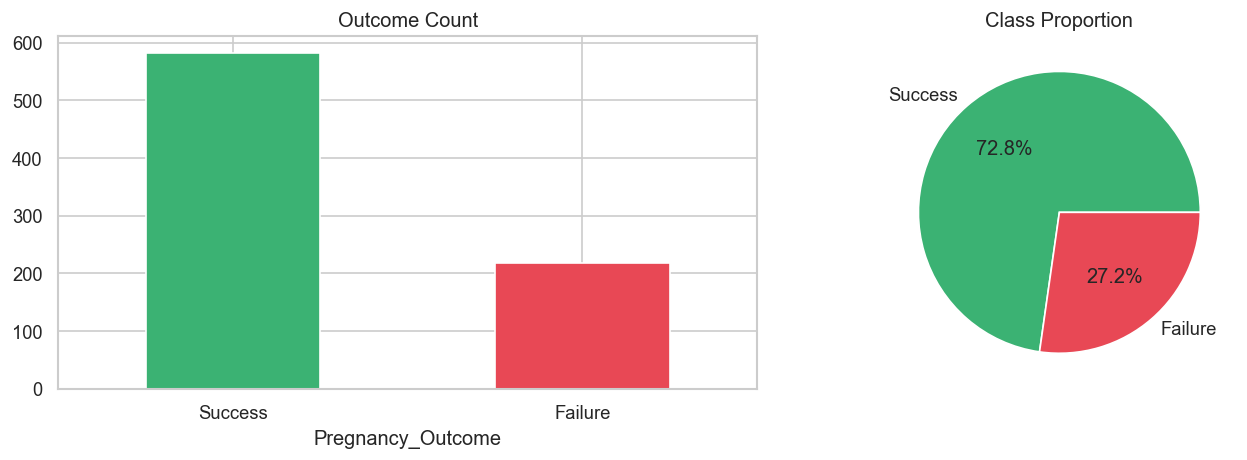

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["Pregnancy_Outcome"].value_counts().plot(kind="bar", ax=axes[0], color=["#3BB273","#E84855"])
axes[0].set_title("Outcome Count")
axes[0].tick_params(axis="x", rotation=0)
df["Pregnancy_Outcome"].value_counts(normalize=True).plot(kind="pie", ax=axes[1], labels=["Success","Failure"], autopct="%1.1f%%", colors=["#3BB273","#E84855"])
axes[1].set_title("Class Proportion")
plt.tight_layout()
plt.savefig("artifacts/plots/eda_target_distribution.png", bbox_inches="tight")
plt.show()

## 3. Female Age Distribution by Outcome

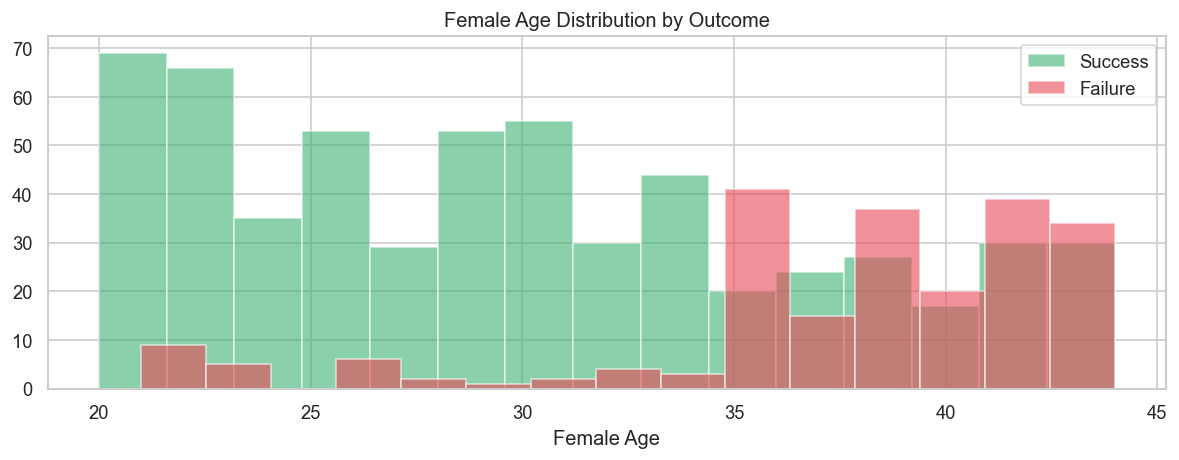

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))
for outcome, color in [("Success","#3BB273"),("Failure","#E84855")]:
    df[df["Pregnancy_Outcome"]==outcome]["Female_Age"].hist(bins=15, alpha=0.6, color=color, label=outcome, ax=ax)
ax.set_xlabel("Female Age")
ax.set_title("Female Age Distribution by Outcome")
ax.legend()
plt.tight_layout()
plt.savefig("artifacts/plots/eda_age_by_outcome.png", bbox_inches="tight")
plt.show()

## 4. Success Rate by Categorical Features

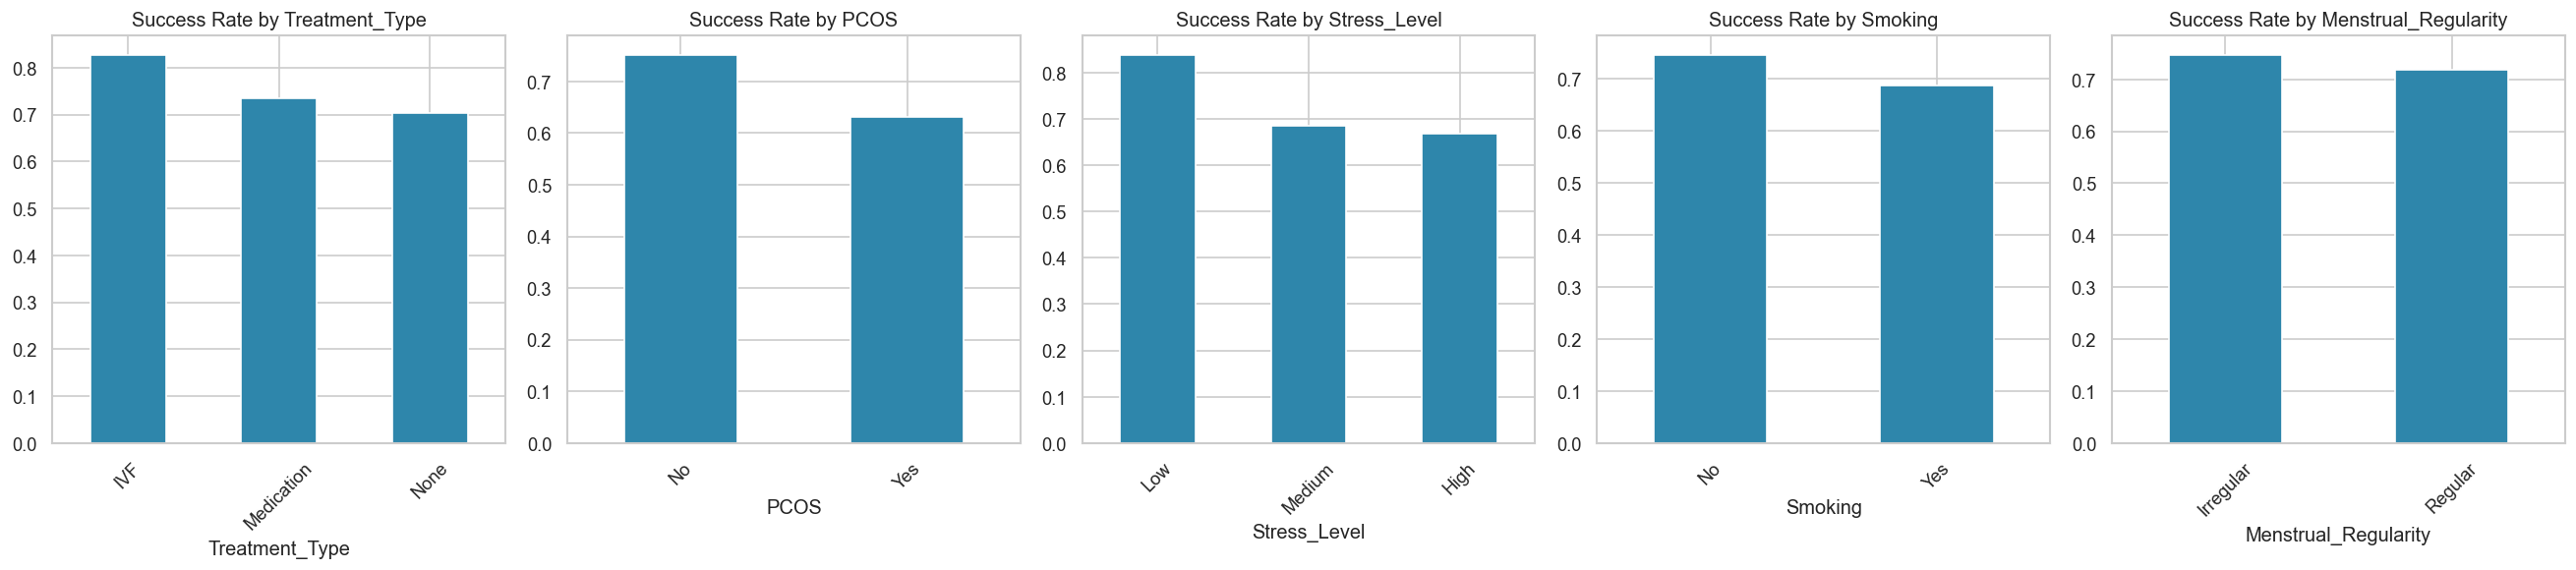

In [5]:
df["success_flag"] = (df["Pregnancy_Outcome"]=="Success").astype(int)
cat_cols = ["Treatment_Type","PCOS","Stress_Level","Smoking","Menstrual_Regularity"]
fig, axes = plt.subplots(1, 5, figsize=(22, 5))
for i, col in enumerate(cat_cols):
    r = df.groupby(col)["success_flag"].mean().sort_values(ascending=False)
    r.plot(kind="bar", ax=axes[i], color="#2E86AB", edgecolor="white")
    axes[i].set_title(f"Success Rate by {col}")
    axes[i].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("artifacts/plots/eda_success_by_category.png", bbox_inches="tight")
plt.show()

## 5. Sperm Metrics vs Outcome

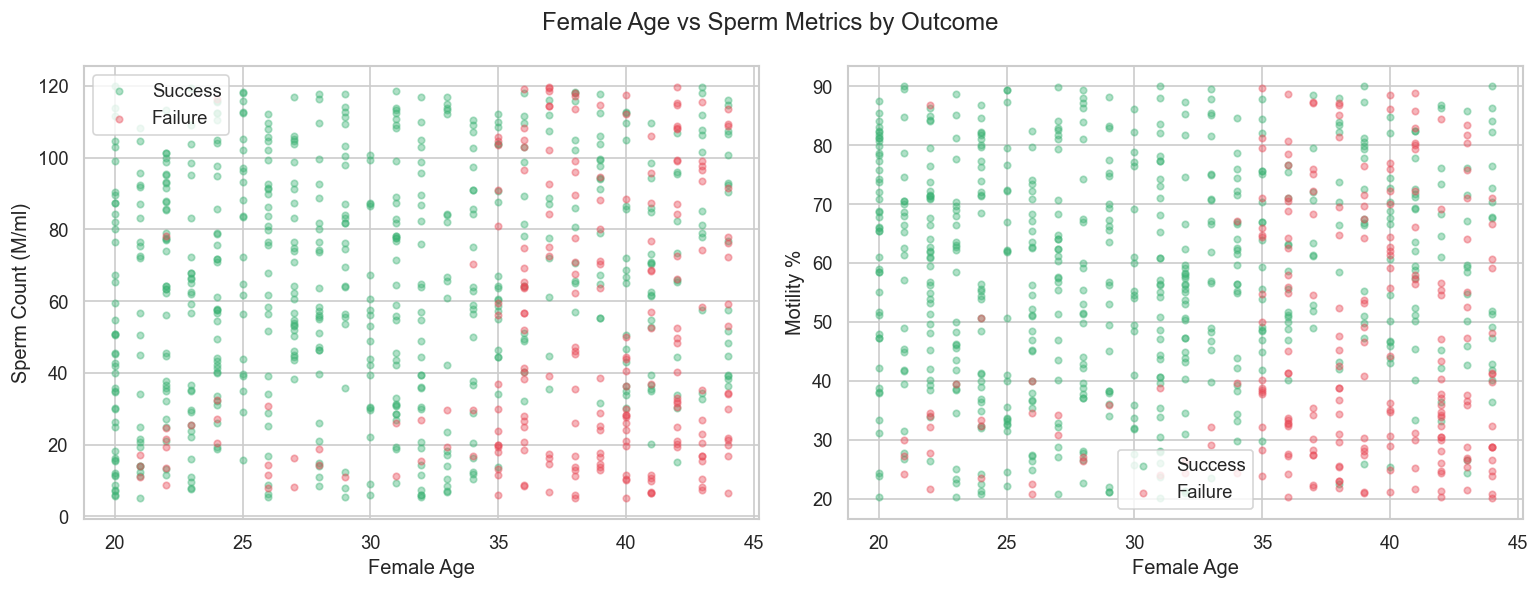

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for outcome, color in [("Success","#3BB273"),("Failure","#E84855")]:
    subset = df[df["Pregnancy_Outcome"]==outcome]
    axes[0].scatter(subset["Female_Age"], subset["Sperm_Count_Million_per_ml"],
                    alpha=0.4, color=color, label=outcome, s=15)
    axes[1].scatter(subset["Female_Age"], subset["Motility_%"],
                    alpha=0.4, color=color, label=outcome, s=15)
for ax, ylabel in zip(axes, ["Sperm Count (M/ml)","Motility %"]):
    ax.set_xlabel("Female Age")
    ax.set_ylabel(ylabel)
    ax.legend()
fig.suptitle("Female Age vs Sperm Metrics by Outcome")
plt.tight_layout()
plt.savefig("artifacts/plots/eda_sperm_metrics.png", bbox_inches="tight")
plt.show()

## 6. Correlation Heatmap

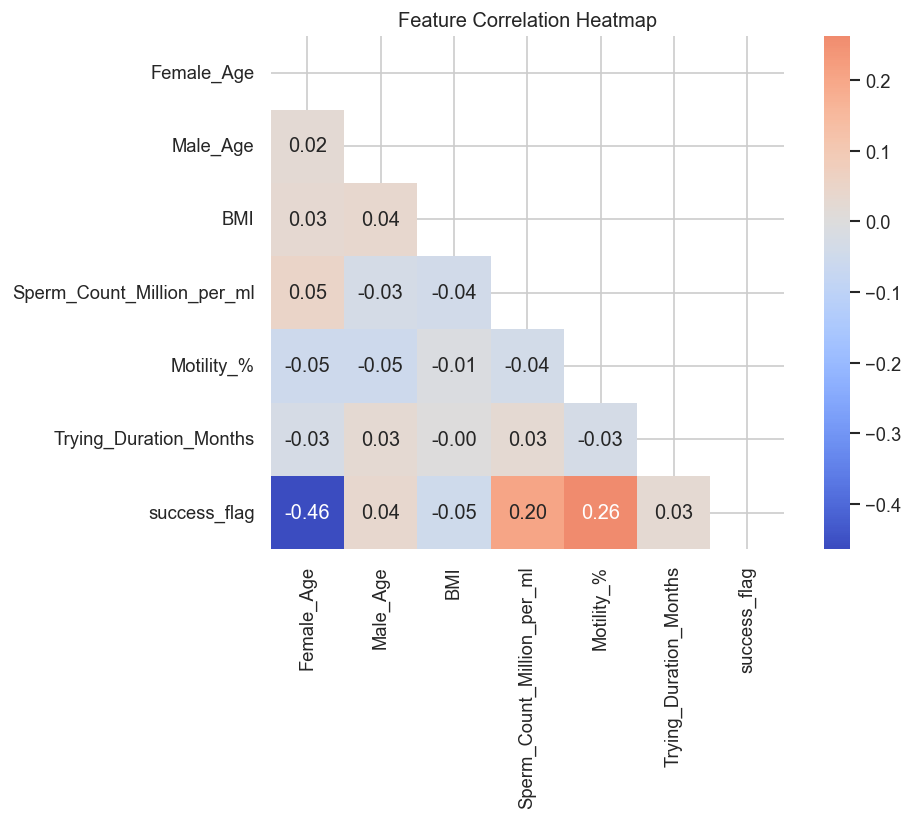

In [7]:
num_cols = ["Female_Age","Male_Age","BMI","Sperm_Count_Million_per_ml","Motility_%","Trying_Duration_Months","success_flag"]
corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, ax=ax)
ax.set_title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig("artifacts/plots/eda_correlation_heatmap.png", bbox_inches="tight")
plt.show()

## Key EDA Takeaways
- **Female Age** is the strongest negative predictor (corr -0.46) -- older women have lower success rates
- **Motility %** and **Sperm Count** are positive predictors
- **IVF treatment** shows highest success rate among treatment types
- **PCOS** reduces success rate from 75% to 63%
- **Stress Level High** reduces success rate vs Low stress (67% vs 84%)
- **Informative NaN strategy** critical -- Treatment NaN means no treatment, not missing data